In [6]:
import pandas as pd
from scripts.aux_msa_functions import *
from scipy.spatial.distance import cdist
import os
import numpy as np
import torch
from Bio import Phylo
import seaborn as sns
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import re
from scipy.stats import pearsonr
from math import floor,ceil
from scipy import stats
import esm

torch.set_grad_enabled(False)

In [3]:
pfam_metadata = pd.read_csv("./data/pfam-metadata/pfam_metadata.tsv", delimiter = "\t")

all_metrics_dataframe = pd.read_csv("./sequence_scores_table.tsv", delimiter = "\t")
all_metrics_dataframe = all_metrics_dataframe.merge(pfam_metadata, left_on = "family", right_on="pfam_id")



In [91]:
all_metrics_dataframe_fam = all_metrics_dataframe.loc[all_metrics_dataframe["pfam_id"] == "PF00271", :].reset_index(drop = True).iloc[:10,:]

In [92]:
sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe["sequence"])]

In [93]:
model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()

In [94]:
batch_converter = alphabet.get_batch_converter()
model.eval() 

_,_, sequences_tensor = batch_converter([sequences])

In [49]:
len(sequences[0][1])

111

In [31]:
sequences_tensor.shape

torch.Size([1, 10, 112])

In [25]:
x = model(sequences_tensor, need_head_weights=True)

In [33]:
column_attns = x["col_attentions"][0]

In [87]:
a = torch.mean(column_attns, axis = [3])
a = torch.mean(a, axis = [2])
a = np.reshape(a, newshape = (-1,10), order = 'C')
a = np.transpose(a).numpy()

In [99]:
a_df = pd.DataFrame(a, columns = [f"col_attn_{i}" for i in range(a.shape[1])])

In [100]:
x = pd.concat([a_df, all_metrics_dataframe_fam], axis = 1)

In [101]:
x

,col_attn_0,col_attn_1,col_attn_2,col_attn_3,col_attn_4,col_attn_5,col_attn_6,col_attn_7,col_attn_8,col_attn_9,...,min_natural_ham_dist_full,max_natural_ham_dist_full,pfam_id,family_name,length,depth,effective_depth,pdb_id,resolution,seed_sizes
0,0.101234,0.105299,0.098144,0.081033,0.122511,0.202585,0.102061,0.115627,0.100913,0.115162,...,0.729730,0.927928,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421
1,0.111356,0.107034,0.097615,0.122790,0.112525,0.109099,0.102586,0.114807,0.100467,0.098565,...,0.720721,0.927928,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421
2,0.102440,0.103437,0.095941,0.106043,0.090650,0.085014,0.119957,0.108733,0.096117,0.092919,...,0.720721,0.927928,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421
3,0.097744,0.099188,0.092738,0.098487,0.094063,0.084748,0.098119,0.096922,0.104191,0.095427,...,0.711712,0.918919,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421
4,0.091987,0.088334,0.096343,0.098217,0.100732,0.094887,0.100491,0.083581,0.093553,0.101723,...,0.702703,0.918919,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421
5,0.101338,0.107279,0.103961,0.114337,0.096898,0.086031,0.095019,0.099292,0.109094,0.094646,...,0.738739,0.927928,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421
6,0.097569,0.089310,0.103941,0.094309,0.094319,0.083708,0.098644,0.103287,0.099712,0.096917,...,0.720721,0.945946,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421
7,0.103113,0.116643,0.104568,0.112673,0.098702,0.081294,0.092622,0.094339,0.107674,0.095876,...,0.702703,0.918919,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421
8,0.095500,0.090313,0.101000,0.083273,0.095577,0.089099,0.093224,0.085514,0.100188,0.103863,...,0.702703,0.927928,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421
9,0.097719,0.093163,0.105748,0.088838,0.094022,0.083536,0.097276,0.097898,0.088092,0.104902,...,0.666667,0.927928,PF00271,Helicase_C,111,66809,25017,3EX7,2.3,421


In [108]:
corr_matrix = np.zeros(144)

for i in range(len(corr_matrix)):

    corr = pearsonr(x[f"col_attn_{i}"], x["hmmer_seq_score_normalized"]).statistic
    corr_matrix[i] = corr

corr_matrix = np.reshape(corr_matrix, newshape = (12,12), order = "C")
# sns.scatterplot(x = "col_attn_10", y = "hmmer_seq_score_normalized", data = x)

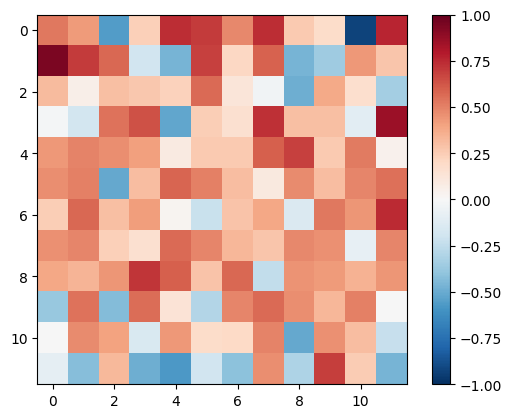

In [114]:
plt.imshow(corr_matrix, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar()